# Comparison of Diversification Approaches

Anonymous project demo — Topic 3

Compare minimum risk, maximum diversification and risk parity with equally weighted
and capitalization-weighted portfolios. All five use the same eligible stock universe,
formation dates, covariance estimate and out-of-sample return conventions.

**Main question:** How do different definitions of diversification change portfolio
risk, concentration, turnover and realized performance?

**Baseline:** January 1995–December 2025 (372 months); 60-month estimation windows;
500 largest eligible US common stocks; monthly rebalancing.

Run every cell in order. The cells below reproduce the performance table, cumulative
returns, drawdowns, subperiod comparison and diversification diagnostics, then repeat the
comparison under the two alternative covariance estimators from `project.pdf` (constant
correlation and the shrunk sample covariance, sections 9–12). A full run takes about one
minute once the CRSP data are cached.

## Reproduction instructions

This submission contains one notebook, one Python file (`project.py`) and one CSV
(`MktRf.csv`, the course-provided market/risk-free data). No original repository is needed.

1. Extract all three files into the same folder. Use Python 3.10 or newer.
2. Install dependencies in your notebook's environment if needed:
   `%pip install numpy pandas matplotlib scipy cvxpy clarabel pyarrow wrds ipykernel`
3. Open `project_demo.ipynb` and choose **Restart Kernel and Run All**.
4. First run: authenticate with your own WRDS account when prompted. The SQL download
   is cached in `data/crsp_msf_v2.parquet`; later runs read that cache. Inside the development repository, the notebook also
   detects `../data/crsp_msf_v2.parquet`. Alternatively, set `CRSP_PATH` to your existing extract from the same query. First-time download
   needs network access, CRSP permissions and enough disk/memory for the monthly panel.

The supplied outputs were generated using the existing project cache. A fresh WRDS
vintage may differ; keep the downloaded cache if you need identical reruns. The live
WRDS authentication/download route is provided but was not exercised for this release.
No credentials, CRSP data, names or personal repository links are included in the ZIP.

`EXPORT_REPORT_ASSETS = True` optionally saves charts and result CSVs; leave it `False`
for the standard demo. Those generated files are not required submission inputs.

The development folder may also contain `report_results/` for slide preparation.
When creating the submission ZIP, include only the three input files listed above.


## 1. Setup

In [1]:
import os, sys, warnings
# Open this notebook with project.py and MktRf.csv in the same directory.
if not os.path.exists("project.py") and os.path.exists("final/project.py"):
    os.chdir("final")
sys.path.insert(0, os.getcwd())

# numpy on macOS Accelerate emits spurious matmul RuntimeWarnings; results are unaffected.
warnings.filterwarnings("ignore", category=RuntimeWarning, message=".*encountered in matmul")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project import (
    rolling_backtest, summarize, select_universe, estimate_single_factor,
    min_risk, min_risk_closed_form, risk_parity, risk_parity_cvxpy, rc_dispersion,
    max_diversification, max_diversification_closed_form, diversification_ratio,
    optimality_residuals, equal_weight, value_weight, returns_from_panel,
    performance_table, subperiod_table,
    estimate_covs, check_alignment, download_crsp, data_quality_report, universe_summary,
    # alternative covariance estimators (sections 9-12)
    ESTIMATORS, strategies, estimate_constant_correlation, estimate_shrunk_sample,
    min_risk_shrunk, max_diversification_shrunk, risk_parity_shrunk,
    # report tables and figures shared by every estimator (sections 6-12)
    COLORS, LABELS, ESTIMATOR_COLORS, ESTIMATOR_LABELS, plot_cumulative, plot_drawdowns,
    concentration_diagnostics, diversification_checks, concentration_table,
    plot_diversification, estimator_comparison, estimator_returns,
)
from pathlib import Path
from IPython.display import display

pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 1.5,
})

# Change these two paths if your input files are elsewhere.
CRSP_PATH = Path("data/crsp_msf_v2.parquet")
# Reuse the development cache when running final/ inside this repository.
# A standalone submission still downloads via WRDS if neither cache exists.
if not CRSP_PATH.exists() and Path("../data/crsp_msf_v2.parquet").exists():
    CRSP_PATH = Path("../data/crsp_msf_v2.parquet")
MARKET_PATH = Path("MktRf.csv")
# Optional chart/CSV exports for preparing slides; disabled for a clean demo.
EXPORT_REPORT_ASSETS = False
ASSET_DIR = Path("report_results")
def save_figure(name):
    if EXPORT_REPORT_ASSETS:
        ASSET_DIR.mkdir(parents=True, exist_ok=True)
        plt.gcf().savefig(ASSET_DIR / f"{name}.png", dpi=220, bbox_inches="tight")

## 2. Data and preparation

CRSP monthly stock file `crsp.msf_v2` (CIZ), January 1990–December 2025. The SQL query
selects US common stocks; we then retain NYSE / NYSE American / Nasdaq exchanges.
CRSP `mthret` is a decimal total return and includes CIZ delisting returns. French
`Mkt-RF` and `RF` are supplied in percentage points and are divided by 100.
Month keys use `yyyymm`. Only stocks with a complete trailing 60-month history are
eligible; among them select the largest 500 by capitalization at the formation date.

The cache is an input convenience; without it, use your own WRDS account. Cached
classification provenance cannot be inferred from columns omitted by the download SQL.


In [2]:
if CRSP_PATH.exists():
    raw = download_crsp(path=CRSP_PATH)
else:
    import wrds
    print("No local CRSP cache. Log in with your own WRDS account to download US common stocks.")
    db = wrds.Connection()
    try:
        raw = download_crsp(db, path=CRSP_PATH)
    finally:
        db.close()
display(data_quality_report(raw).to_frame("value"))

Loaded ../data/crsp_msf_v2.parquet: (2179752, 14)


,value
rows,2179752
unique permnos,18905
first month,199001
last month,202512
"duplicate (permno, month)",0
missing mthret (%),1.8270
missing mthcap (%),1.7930
returns < -100%,0
returns > +100%,7313
returns > +300%,526


In [3]:
# Same preparation as the other notebooks: NYSE / NYSE American / Nasdaq only, keyed on yyyymm.
assert not raw.duplicated(["yyyymm", "permno"]).any(), "duplicate stock-month observations"
crsp = raw[raw.primaryexch.isin(["N", "A", "Q"])]
rets = crsp.pivot_table(index="yyyymm", columns="permno", values="mthret")
caps = crsp.pivot_table(index="yyyymm", columns="permno", values="mthcap")
sic = crsp.pivot(index="yyyymm", columns="permno", values="siccd")  # sector diagnostic, section 10

ff = pd.read_csv(MARKET_PATH, index_col=0)
mkt = (ff["Mkt-RF"] / 100.0).reindex(rets.index)
rf = (ff["RF"] / 100.0).reindex(rets.index)

assert not mkt.isna().any() and not rf.isna().any(), "MktRf does not cover the CRSP window"
assert 0.03 < mkt.std() < 0.07, "Mkt-RF units look wrong -- did you divide by 100?"
assert rets.min().min() >= -1.0, "a return below -100% is impossible"
print(f"panel {rets.shape[0]} months x {rets.shape[1]:,} stocks, {rets.index[0]}..{rets.index[-1]}")

panel 432 months x 18,898 stocks, 199001..202512


## 3. Parameters and universe summary

In [4]:
START_YEAR, END_YEAR, T, N = 1995, 2025, 60, 500

idx = rets.index
i_first = idx.get_loc(START_YEAR * 100 + 1) - 1   # last in-sample month before 1995-01
i_last = idx.get_loc(END_YEAR * 100 + 12) - 1
print(f"rebalances {idx[i_first]}..{idx[i_last]}, out-of-sample {idx[i_first + 1]}..{idx[i_last + 1]}, "
      f"{i_last - i_first + 1} months")

rebalances 199412..202511, out-of-sample 199501..202512, 372 months


In [5]:
us = universe_summary(rets, caps, T, N, start=idx[i_first], end=idx[i_last])
us.describe().T

,count,mean,std,min,25%,50%,75%,max
n_eligible,372.0000,"3,252.6478",515.8474,"2,592.0000","2,706.5000","3,130.5000","3,818.2500","4,059.0000"
n_universe,372.0000,500.0000,0.0000,500.0000,500.0000,500.0000,500.0000,500.0000
min_cap_musd,372.0000,"5,119.6468","2,689.3526","1,475.2260","2,803.8285","4,249.1475","6,763.4747","11,849.6783"
median_cap_musd,372.0000,"13,840.5208","8,117.7502","3,472.9826","7,573.1825","11,003.6787","17,964.5626","35,353.6271"
share_of_total_cap,372.0000,0.8026,0.0391,0.7114,0.7834,0.8035,0.8193,0.8943
top10_weight_vw,372.0000,0.2260,0.0489,0.1665,0.1906,0.2097,0.2452,0.4051
new_names,371.0000,12.4690,4.6523,3.0000,9.5000,11.0000,14.0000,34.0000
missing_next_ret,372.0000,1.5376,1.4889,0.0000,0.0000,1.0000,2.0000,9.0000


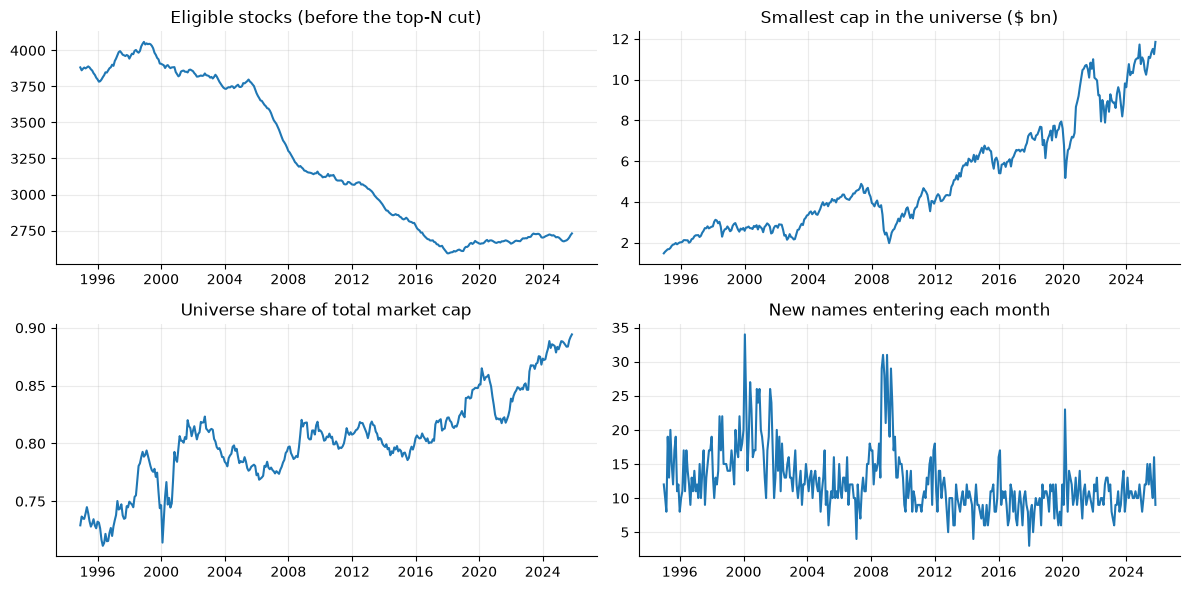

In [6]:
fig, ax = plt.subplots(2, 2, figsize=(12, 6))
when_us = pd.PeriodIndex([str(d) for d in us.index], freq="M").to_timestamp()
ax[0, 0].plot(when_us, us.n_eligible); ax[0, 0].set_title("Eligible stocks (before the top-N cut)")
ax[0, 1].plot(when_us, us.min_cap_musd / 1e3); ax[0, 1].set_title("Smallest cap in the universe ($ bn)")
ax[1, 0].plot(when_us, us.share_of_total_cap); ax[1, 0].set_title("Universe share of total market cap")
ax[1, 1].plot(when_us, us.new_names); ax[1, 1].set_title("New names entering each month")
plt.tight_layout(); save_figure("universe"); plt.show()

## 4. Backtest

One call runs every strategy on the same universe and covariance estimate each month.
`check_alignment` then confirms identical months, rebalance dates and universes, and fully
invested long-only weights.

### Covariance and portfolio definitions

All portfolios satisfy $\mathbf{1}'x=1$, $x\geq0$.

$V=\sigma_M^2\beta\beta'+\operatorname{Diag}(\omega^2)$ uses trailing-window OLS
on **excess** returns, an intercept, residual variance with $T-2$ degrees of freedom,
and Blume beta shrinkage $\beta=(2/3)\widehat\beta+1/3$. Residual variance is not shrunk.

| Strategy | Rule |
|---|---|
| EW | $x_i=1/n$ |
| VW | $x_i=\mathrm{cap}_i/\sum_j\mathrm{cap}_j$ |
| Minimum risk | minimize $x'Vx$ |
| Maximum diversification | maximize $DR=(\sigma'x)/\sqrt{x'Vx}$, with $\sigma_i=\sqrt{V_{ii}}$ |
| Risk parity | equalize $x_i(Vx)_i/\sqrt{x'Vx}$ across stocks |

Analytic scalar-root solutions speed monthly optimization. MaxDiv uses an open-source
QP when the positive-beta threshold assumptions do not apply. No expected-return
forecast, leverage, position cap or transaction-cost penalty is used. Sections 9–12 replace
the single-factor model with two alternative covariance estimators.

### Numerical validation at the first rebalance

Compare the analytic weights/objectives with independent optimization routines;
check that each portfolio is fully invested and long only. Later cells check every
formation date for alignment, MaxDiv optimality and risk-parity equal contributions.


In [7]:
t = idx[i_first]
window = idx[i_first-T+1:i_first+1]
universe = select_universe(rets, caps, window, t, N)
cov = estimate_single_factor(rets.loc[window, universe].values - rf.loc[window].values[:, None],
                             mkt.loc[window].values, permno=universe.values)
mr_cf, mr_qp = min_risk_closed_form(cov), min_risk(cov)
md_cf, md_qp = max_diversification_closed_form(cov), max_diversification(cov)
rp_cf, rp_cp = risk_parity(cov)["x"], risk_parity_cvxpy(cov)
assert abs(mr_cf["sigma2"] / mr_qp["sigma2"] - 1) < 1e-4
assert abs(diversification_ratio(md_cf["x"], cov) - diversification_ratio(md_qp["x"], cov)) < 1e-6
assert rc_dispersion(rp_cf, cov) < 1e-8
assert np.max(np.abs(rp_cf - rp_cp)) < 1e-5
for x in [mr_cf["x"], md_cf["x"], rp_cf]:
    assert np.isfinite(x).all() and x.min() >= 0 and abs(x.sum()-1) < 1e-10
print("First-rebalance min-risk QP, MaxDiv QP and risk-parity convex checks passed.")


First-rebalance min-risk QP, MaxDiv QP and risk-parity convex checks passed.


In [8]:
STRATEGIES = {
    "ew": equal_weight,
    "vw": value_weight,
    "min_risk": min_risk_closed_form,
    "risk_parity": risk_parity,
    "max_div": max_diversification_closed_form,
}

panel, weights = rolling_backtest(rets, caps, mkt, rf, T=T, n=N,
                                  start=idx[i_first], end=idx[i_last],
                                  constructors=STRATEGIES)
returns = returns_from_panel(panel)[list(STRATEGIES)]

check_alignment(returns, weights, asset_returns=rets)
assert len(returns) == i_last - i_first + 1
print(f"{len(returns)} months x {returns.shape[1]} strategies; alignment checks passed")

372 months x 5 strategies; alignment checks passed


## 5. Summary statistics

Conventions (`project.py`): geometric annualised return; volatility and Sharpe
ratio on **excess** returns; maximum drawdown on the compounded path; beta against the market
excess return; one-way turnover against the previous month's **drifted** weights.
The table is cross-checked against `summarize`.

In [9]:
table = performance_table(returns, weights, rf=rf, asset_returns=rets, mkt=mkt)

ref = summarize(panel)
for col in ["ann_return", "ann_vol", "sharpe", "max_drawdown", "ann_turnover"]:
    gap = np.abs(table[col] - ref.loc[table.index, col]).max()
    assert gap < 1e-12, f"{col} disagrees with summarize by {gap:.1e}"

table.rename(index=lambda k: LABELS.get(k, k))
# Exhibit 1-style comparison: strategies as columns, metrics as rows.
# The article reports arithmetic excess returns; show that convention alongside CAGR.
exhibit = table[["ann_return", "ann_vol", "sharpe", "beta", "max_drawdown", "ann_turnover"]].copy()
exhibit["ann_excess_mean"] = returns.sub(rf.reindex(returns.index), axis=0).mean() * 12
exhibit["avg_n_held"] = ref.avg_n_held
exhibit["avg_eff_n"] = ref.avg_eff_n
EXHIBIT_ROWS = {
    "ann_excess_mean": "Annual arithmetic excess return (%)",
    "ann_return": "Total-return CAGR (%)",
    "ann_vol": "Annual excess-return volatility (%)",
    "sharpe": "Sharpe ratio",
    "beta": "Realized market beta",
    "avg_n_held": "Average holdings",
    "avg_eff_n": "Average effective N (weights)",
    "max_drawdown": "Maximum drawdown (%)",
    "ann_turnover": "Annual one-way turnover (%)",
}
exhibit = exhibit[list(EXHIBIT_ROWS)].rename(columns=EXHIBIT_ROWS, index=LABELS).T
for key in [k for k in exhibit.index if "(%)" in k]:
    exhibit.loc[key] *= 100
print("Exhibit 1-style five-strategy comparison, 1995–2025 (gross of trading costs)")
display(exhibit.round(3))


Exhibit 1-style five-strategy comparison, 1995–2025 (gross of trading costs)


,Equally weighted,Value weighted,Minimum risk,Risk parity,Maximum diversification
Annual arithmetic excess return (%),9.9390,9.7180,6.3520,9.6730,8.5170
Total-return CAGR (%),11.6300,11.5460,8.2030,11.6210,10.3460
Annual excess-return volatility (%),15.7440,14.8210,12.7240,14.0390,14.1080
Sharpe ratio,0.6310,0.6560,0.4990,0.6890,0.6040
Realized market beta,0.9770,0.9440,0.3390,0.8460,0.6730
Average holdings,500.0000,500.0000,45.1160,500.0000,63.0430
Average effective N (weights),500.0000,112.2820,25.3440,423.6350,36.7300
Maximum drawdown (%),-51.6960,-49.1310,-37.5490,-48.9030,-53.6210
Annual one-way turnover (%),61.6550,10.0110,116.6170,62.4100,160.3570


## 6. Cumulative returns

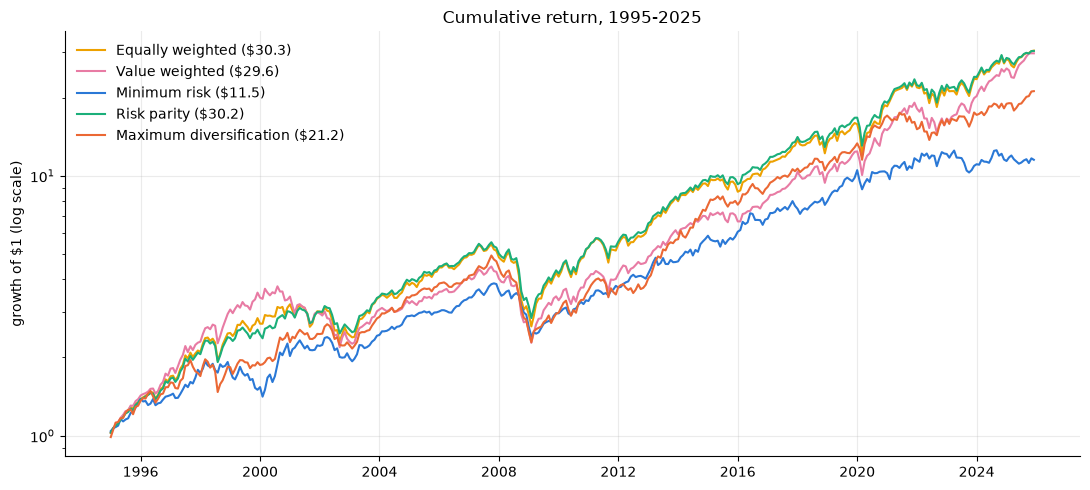

In [10]:
plot_cumulative(returns, f"Cumulative return, {START_YEAR}-{END_YEAR}")
save_figure("cumulative_returns"); plt.show()

## 7. Drawdowns and economic subperiods

The running peak includes initial wealth of $1. All five portfolios are evaluated over the same subperiods; results are gross of transaction costs.

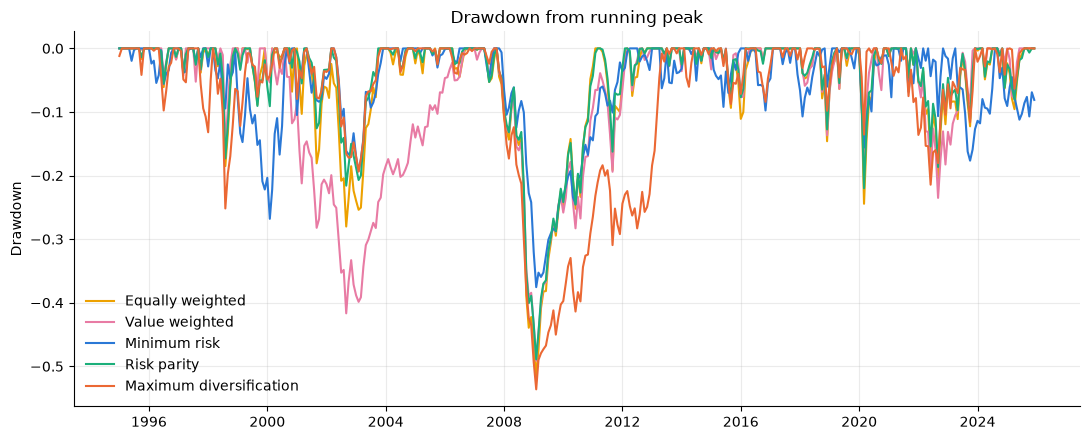

ann_return  ann_vol  sharpe  max_drawdown   beta
period    strategy                                                                 
1995–1999 Equally weighted             0.2316   0.1395  1.2173       -0.1851 0.9350
          Value weighted               0.2885   0.1396  1.5466       -0.1522 0.9512
          Minimum risk                 0.0848   0.1308  0.3070       -0.2219 0.3382
          Risk parity                  0.2067   0.1302  1.1347       -0.1729 0.8481
          Maximum diversification      0.1391   0.1639  0.5760       -0.2518 0.9512
2000–2002 Equally weighted            -0.0427   0.1849 -0.3450       -0.2802 0.8728
          Value weighted              -0.1273   0.1797 -0.8721       -0.4167 0.8945
          Minimum risk                 0.1138   0.1823  0.4801       -0.1667 0.0207
          Risk parity                  0.0082   0.1499 -0.1189       -0.2159 0.5961
          Maximum diversification      0.0605   0.1404  0.2243       -0.1719 0.1829
2003–2006 Equally weighted             0.1823   0.0985  1.5082       -0.0448 1.0704
          Value weighted               0.1414   0.0822  1.3567       -0.0431 0.9046
          Minimum risk                 0.1262   0.0751  1.2973       -0.0688 0.5697
          Risk parity                  0.1709   0.0822  1.6715       -0.0461 0.8860
          Maximum diversification      0.1480   0.0776  1.5087       -0.0541 0.6486
2007–2009 Equally weighted            -0.0452   0.2198 -0.1933       -0.5170 1.0792
          Value weighted              -0.0499   0.1901 -0.2824       -0.4913 0.9393
          Minimum risk                -0.0392   0.1379 -0.3703       -0.3755 0.5513
          Risk parity                 -0.0425   0.1971 -0.2260       -0.4890 0.9719
          Maximum diversification     -0.0948   0.1790 -0.5804       -0.5362 0.8004
2010–2019 Equally weighted             0.1420   0.1344  1.0221       -0.1914 1.0276
          Value weighted               0.1366   0.1242  1.0566       -0.1614 0.9559
          Minimum risk                 0.1275   0.1052  1.1493       -0.1071 0.2977
          Risk parity                  0.1448   0.1194  1.1545       -0.1624 0.9097
          Maximum diversification      0.1589   0.1252  1.2065       -0.1539 0.7482
2020–2025 Equally weighted             0.1127   0.1825  0.5323       -0.2444 0.9841
          Value weighted               0.1565   0.1719  0.7808       -0.2351 0.9627
          Minimum risk                 0.0267   0.1448  0.0688       -0.1766 0.4341
          Risk parity                  0.1036   0.1684  0.5131       -0.2200 0.8982
          Maximum diversification      0.0862   0.1536  0.4418       -0.2144 0.7069

In [11]:
plot_drawdowns(returns)
save_figure("drawdowns"); plt.show()

PERIODS = [(199501, 199912, "1995–1999"), (200001, 200212, "2000–2002"), (200301, 200612, "2003–2006"),
           (200701, 200912, "2007–2009"),
           (201001, 201912, "2010–2019"), (202001, 202512, "2020–2025")]
SUB_COLS = ["ann_return", "ann_vol", "sharpe", "max_drawdown", "beta"]
sub = subperiod_table(returns, weights, periods=PERIODS, rf=rf, asset_returns=rets, mkt=mkt)
display(sub[SUB_COLS].rename(index=LABELS, level="strategy"))

## 8. Diversification and risk concentration

DR uses model-implied asset volatilities and the same covariance for every strategy. Effective risk contribution count measures concentration across stocks, rather than independent risk sources. The market variance share measures factor concentration. MaxDiv maximizes estimated DR; it need not have the most holdings or the highest realized Sharpe.

MaxDiv maximum relative KKT residual: 2.85e-09
Maximum risk-parity contribution dispersion: 2.94e-14


,div_ratio,n_held,eff_n_weight,eff_n_risk,top10_rc_share,systematic_share
Equally weighted,2.1167,500.0000,500.0000,437.0646,0.0453,0.9912
Value weighted,1.9459,500.0000,112.2817,102.9371,0.2480,0.9755
Minimum risk,2.8875,45.1156,25.3440,25.3440,0.5398,0.7316
Risk parity,2.2572,500.0000,423.6350,500.0000,0.0200,0.9893
Maximum diversification,3.6607,63.0430,36.7298,37.9566,0.4113,0.6548


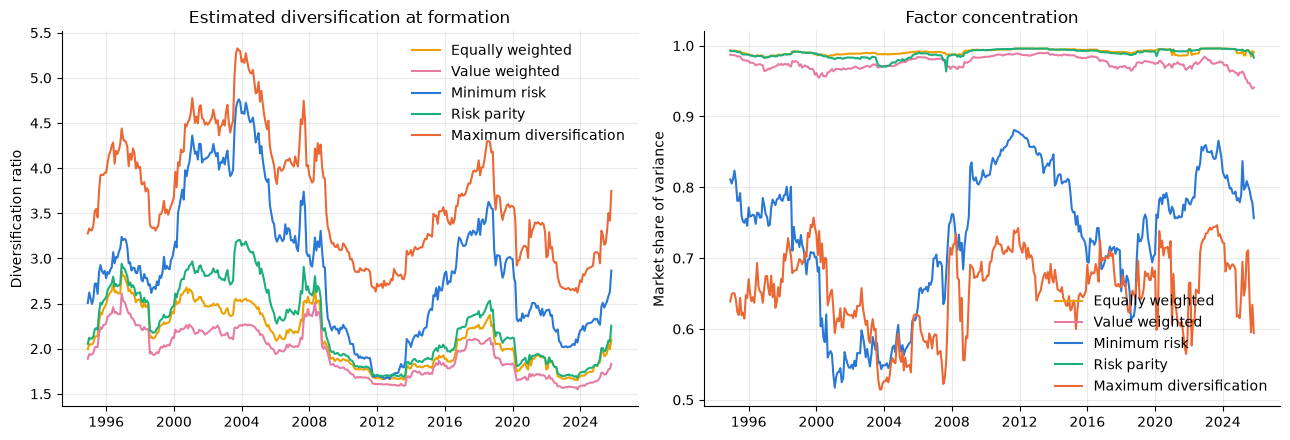

In [12]:
covs = estimate_covs(weights["max_div"], rets, mkt, rf, T=T)
conc = concentration_diagnostics(weights, covs)
checks = diversification_checks(weights, covs, conc)
assert checks["dr_excess"] <= 1e-6        # MaxDiv has the highest estimated DR on every date
assert checks["max_kkt"] < 1e-8
assert checks["max_rp_dispersion"] < 1e-8
dr = pd.DataFrame({k: c.div_ratio for k, c in conc.items()})
assert np.max(np.abs(dr["ew"] - dr["risk_parity"])) > 0  # strategies are not duplicated
print(f"MaxDiv maximum relative KKT residual: {checks['max_kkt']:.2e}")
print(f"Maximum risk-parity contribution dispersion: {checks['max_rp_dispersion']:.2e}")

conc_table = concentration_table(conc)
display(conc_table)
plot_diversification(conc)
save_figure("diversification"); plt.show()

## 9. Alternative covariance estimators

Sections 4–8 use the single-factor model, which assumes uncorrelated residuals: stocks that
share an industry shock look more diversifiable than they are. We repeat the backtest with
the two alternatives on the last page of `project.pdf`, keeping the universe, dates and
constraints unchanged.

| Estimator | Covariance | Estimation |
|---|---|---|
| Constant correlation | $V=\rho\,\sigma\sigma'+(1-\rho)\operatorname{Diag}(\sigma)^2$ | $\rho$ = average pairwise sample correlation; log volatilities shrunk 1/3 towards their mean |
| Shrunk sample | $V=\hat V+\lambda(C-\hat V)$, $\hat V=RR'$ | $C$: average variance on the diagonal, average covariance off it; $\lambda$ from the Clarke–de Silva–Thorley (2006) appendix, clipped to $[0,1]$; sample means ignored |

* The constant-correlation matrix is again "rank one plus diagonal", so the closed-form
  optimizers are reused. Under constant correlation, maximum diversification and risk parity
  both reduce to inverse-volatility weights, so their results coincide by construction.
* The shrunk sample covariance is stored as $a\,RR'+bI+c\,\mathbf{1}\mathbf{1}'$. Minimum risk
  and MaxDiv are solved as QPs with an open-source solver; risk parity uses Newton's method.
* Ex-ante and realized betas, and the market share of variance, are always measured with the
  single-factor model, so they are comparable across estimators. EW and VW use no covariance
  and are identical in every run.

### First-rebalance validation

In [13]:
import cvxpy as cp

X = rets.loc[window, universe].values - rf.loc[window].values[:, None]
cc, ss = estimate_constant_correlation(X, universe.values), estimate_shrunk_sample(X, universe.values)

# Constant correlation: rho is the mean off-diagonal sample correlation; MaxDiv = RP = inverse volatility.
rho = (cc.beta[0] / cc.sigma[0]) ** 2
assert abs(rho - (np.corrcoef(X.T).sum() - N) / (N * (N - 1))) < 1e-12
inv_vol = (1 / cc.sigma) / (1 / cc.sigma).sum()
assert np.max(np.abs(max_diversification_closed_form(cc)["x"] - inv_vol)) < 1e-10
assert np.max(np.abs(risk_parity(cc)["x"] - inv_vol)) < 1e-10

# Shrunk sample: lambda and V match a direct dense computation of the formulas in project.pdf.
Vhat = X.T @ X
dbar, cbar = np.trace(Vhat) / N, (Vhat.sum() - np.trace(Vhat)) / (N * (N - 1))
C = np.full((N, N), cbar); np.fill_diagonal(C, dbar)
lam = np.clip((((X**2).T @ X**2).sum() - (Vhat**2).sum() / T) / ((Vhat - C)**2).sum(), 0, 1)
V_dense = (Vhat + lam * (C - Vhat)) / T
assert abs(ss.lam - lam) < 1e-10
assert np.abs(ss.to_dense() - V_dense).max() < 1e-12 * np.abs(V_dense).max()

# Optimizers on the shrunk sample covariance against a dense QP and their optimality conditions.
y = cp.Variable(N, nonneg=True)
dense_qp = cp.Problem(cp.Minimize(cp.quad_form(y, cp.psd_wrap(V_dense))), [cp.sum(y) == 1])
dense_qp.solve(solver=cp.CLARABEL)
assert abs(ss.quad(min_risk_shrunk(ss)["x"]) / dense_qp.value - 1) < 1e-4
assert max(optimality_residuals(max_diversification_shrunk(ss)["x"], ss).values()) < 1e-6
assert rc_dispersion(risk_parity_shrunk(ss)["x"], ss) < 1e-8
print(f"rho = {rho:.3f}, lambda = {ss.lam:.3f}: constant-correlation and shrunk-sample checks passed.")

rho = 0.269, lambda = 0.464: constant-correlation and shrunk-sample checks passed.


### Backtests

In [14]:
assert STRATEGIES == strategies("single_factor")
runs = {"single_factor": dict(returns=returns, weights=weights, panel=panel)}
for est in ["const_corr", "shrunk_sample"]:
    p, w = rolling_backtest(rets, caps, mkt, rf, T=T, n=N, start=idx[i_first], end=idx[i_last],
                            constructors=strategies(est), estimator=est)
    r = returns_from_panel(p)[list(STRATEGIES)]
    check_alignment(r, w, asset_returns=rets)
    assert w["ew"].notna().equals(weights["ew"].notna())                # same universes and dates
    assert np.array_equal(r[["ew", "vw"]].values, returns[["ew", "vw"]].values)  # benchmarks unchanged
    runs[est] = dict(returns=r, weights=w, panel=p)
print(f"{len(runs)} estimators x {returns.shape[1]} strategies x {len(returns)} months; alignment checks passed")

3 estimators x 5 strategies x 372 months; alignment checks passed


## 10. Does the covariance estimator matter?

Each optimized strategy under each estimator, with EW and VW as references (1995–2025, gross of
trading costs). *Pred / realized vol* is average ex-ante volatility divided by realized
volatility: below one means the model underestimated risk. *Utilities weight* is the average
weight in SIC 4900–4999 at formation. For EW and VW the ratio uses the single-factor model.

In [15]:
comparison = estimator_comparison(runs, rf=rf, mkt=mkt, sic=sic)
display(comparison.round(3))

CAGR (%)  Volatility (%)  Sharpe  Max drawdown (%)  Realized beta  Turnover (%)  \
Strategy                Risk model                                                                                              
Minimum risk            Single factor           8.2030         12.7240  0.4990          -37.5490         0.3390      116.6170   
                        Constant correlation    9.0730         12.2400  0.5800          -34.7600         0.3830       95.5520   
                        Shrunk sample          10.0400         11.7530  0.6750          -40.9790         0.6050      180.4350   
Maximum diversification Single factor          10.3460         14.1080  0.6040          -53.6210         0.6730      160.3570   
                        Constant correlation   11.6260         14.8110  0.6610          -49.7050         0.9040       57.0510   
                        Shrunk sample          10.0100         15.9540  0.5320          -58.5140         0.8620      260.7920   
Risk parity             Single factor          11.6210         14.0390  0.6890          -48.9030         0.8460       62.4100   
                        Constant correlation   11.6260         14.8110  0.6610          -49.7050         0.9040       57.0510   
                        Shrunk sample          11.5550         14.8390  0.6560          -49.9820         0.9110       64.4700   
Equally weighted        Benchmark              11.6300         15.7440  0.6310          -51.6960         0.9770       61.6550   
Value weighted          Benchmark              11.5460         14.8210  0.6560          -49.1310         0.9440       10.0110   

                                              Pred / realized vol  Avg holdings  Utilities weight (%)  
Strategy                Risk model                                                                     
Minimum risk            Single factor                      0.5740       45.1160               52.3870  
                        Constant correlation               0.8340       42.2740               42.1780  
                        Shrunk sample                      1.1060      108.0510               20.0210  
Maximum diversification Single factor                      0.7480       63.0430               18.0560  
                        Constant correlation               0.9760      500.0000                9.6590  
                        Shrunk sample                      0.9460       71.7900               12.7240  
Risk parity             Single factor                      0.9410      500.0000               12.1650  
                        Constant correlation               0.9760      500.0000                9.6590  
                        Shrunk sample                      1.0590      500.0000                9.7370  
Equally weighted        Benchmark                          0.9680      500.0000                7.8340  
Value weighted          Benchmark                          1.0020      500.0000                3.7090

One chart per diversification approach: the same rule under the three estimators, with EW and VW as
references. Under constant correlation, MaxDiv is the inverse-volatility portfolio, which tracks EW so
closely that the two lines overlap in the second chart.

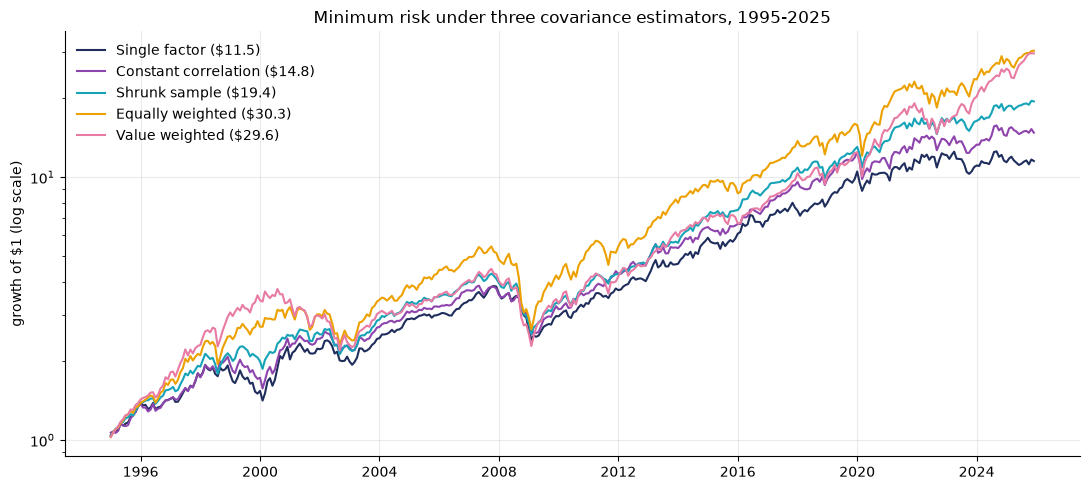

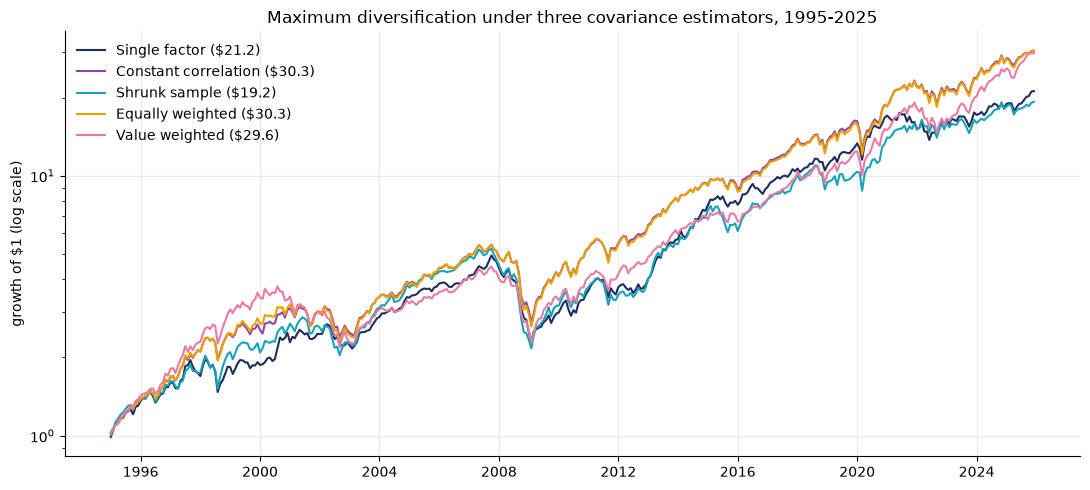

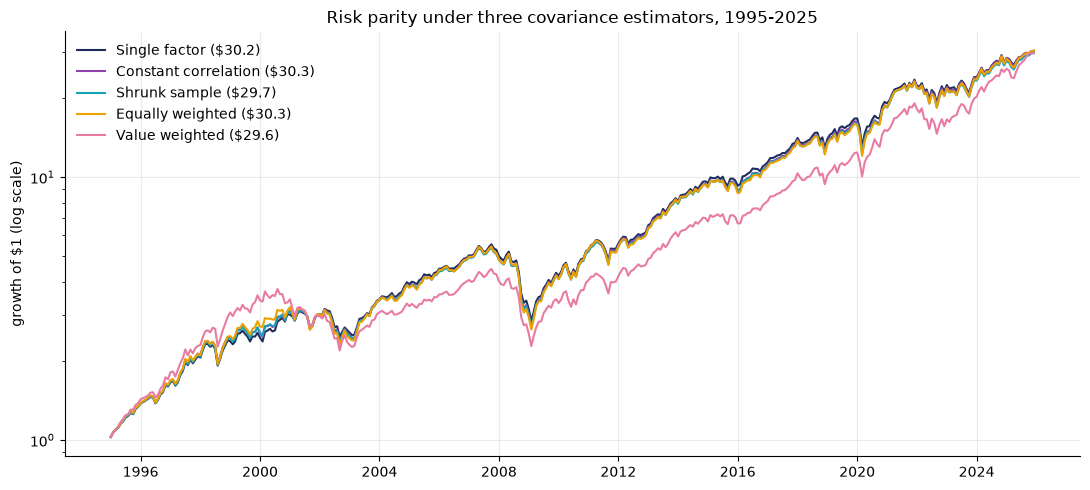

In [16]:
for k in ["min_risk", "max_div", "risk_parity"]:
    plot_cumulative(estimator_returns(runs, k),
                    f"{LABELS[k]} under three covariance estimators, {START_YEAR}-{END_YEAR}",
                    colors={**COLORS, **ESTIMATOR_COLORS}, labels={**LABELS, **ESTIMATOR_LABELS})
    save_figure(f"cumulative_by_estimator_{k}"); plt.show()

## 11. Constant correlation: sections 6–8 repeated

Maximum diversification and risk parity hold the same inverse-volatility portfolio under this
estimator, so their lines overlap.

### 11.1 Cumulative returns (constant correlation)

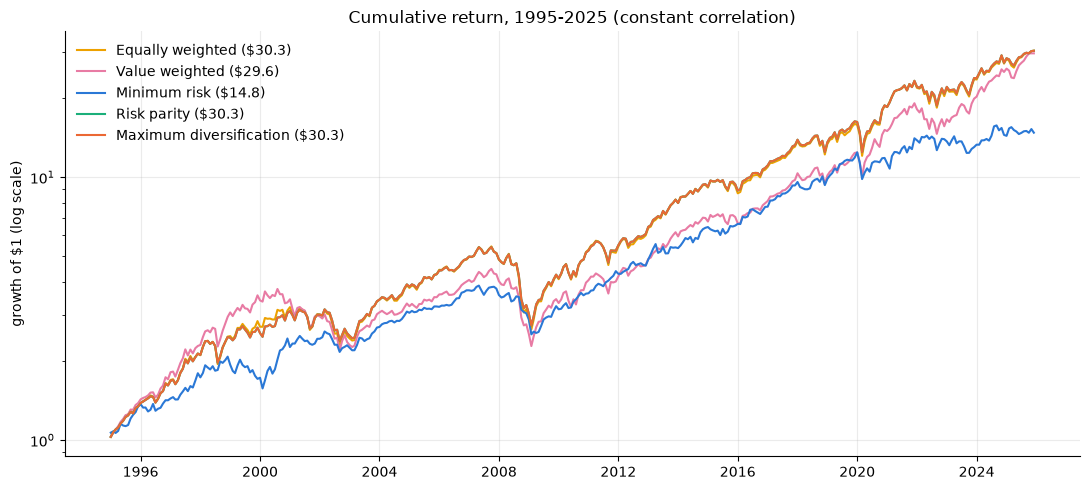

In [17]:
r_cc, w_cc = runs["const_corr"]["returns"], runs["const_corr"]["weights"]
plot_cumulative(r_cc, f"Cumulative return, {START_YEAR}-{END_YEAR} (constant correlation)")
save_figure("cumulative_returns_const_corr"); plt.show()

### 11.2 Drawdowns and economic subperiods (constant correlation)

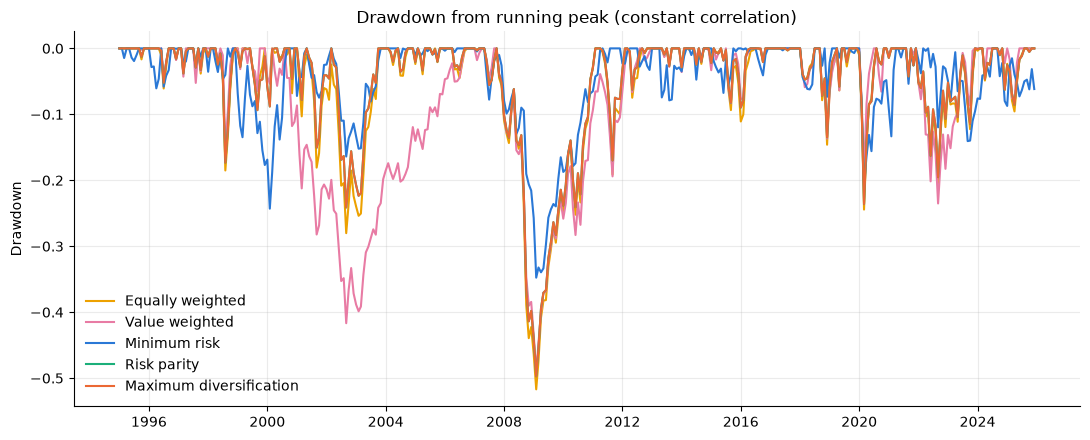

ann_return  ann_vol  sharpe  max_drawdown   beta
period    strategy                                                                 
1995–1999 Equally weighted             0.2316   0.1395  1.2173       -0.1851 0.9350
          Value weighted               0.2885   0.1396  1.5466       -0.1522 0.9512
          Minimum risk                 0.1131   0.1284  0.5116       -0.1768 0.2878
          Risk parity                  0.2176   0.1324  1.1871       -0.1731 0.8668
          Maximum diversification      0.2176   0.1324  1.1871       -0.1731 0.8668
2000–2002 Equally weighted            -0.0427   0.1849 -0.3450       -0.2802 0.8728
          Value weighted              -0.1273   0.1797 -0.8721       -0.4167 0.8945
          Minimum risk                 0.1031   0.1518  0.4803       -0.1640 0.1317
          Risk parity                 -0.0160   0.1694 -0.2306       -0.2411 0.7366
          Maximum diversification     -0.0160   0.1694 -0.2306       -0.2411 0.7366
2003–2006 Equally weighted             0.1823   0.0985  1.5082       -0.0448 1.0704
          Value weighted               0.1414   0.0822  1.3567       -0.0431 0.9046
          Minimum risk                 0.1279   0.0657  1.4966       -0.0433 0.5370
          Risk parity                  0.1764   0.0908  1.5734       -0.0430 0.9906
          Maximum diversification      0.1764   0.0908  1.5734       -0.0430 0.9906
2007–2009 Equally weighted            -0.0452   0.2198 -0.1933       -0.5170 1.0792
          Value weighted              -0.0499   0.1901 -0.2824       -0.4913 0.9393
          Minimum risk                -0.0454   0.1414 -0.4037       -0.3476 0.5436
          Risk parity                 -0.0446   0.2071 -0.2154       -0.4971 1.0196
          Maximum diversification     -0.0446   0.2071 -0.2154       -0.4971 1.0196
2010–2019 Equally weighted             0.1420   0.1344  1.0221       -0.1914 1.0276
          Value weighted               0.1366   0.1242  1.0566       -0.1614 0.9559
          Minimum risk                 0.1390   0.0967  1.3479       -0.0788 0.3748
          Risk parity                  0.1437   0.1253  1.0989       -0.1698 0.9579
          Maximum diversification      0.1437   0.1253  1.0989       -0.1698 0.9579
2020–2025 Equally weighted             0.1127   0.1825  0.5323       -0.2444 0.9841
          Value weighted               0.1565   0.1719  0.7808       -0.2351 0.9627
          Minimum risk                 0.0371   0.1529  0.1396       -0.2090 0.4948
          Risk parity                  0.1085   0.1754  0.5247       -0.2360 0.9383
          Maximum diversification      0.1085   0.1754  0.5247       -0.2360 0.9383

In [18]:
plot_drawdowns(r_cc, "Drawdown from running peak (constant correlation)")
save_figure("drawdowns_const_corr"); plt.show()

sub_cc = subperiod_table(r_cc, w_cc, periods=PERIODS, rf=rf, asset_returns=rets, mkt=mkt)
display(sub_cc[SUB_COLS].rename(index=LABELS, level="strategy"))

### 11.3 Diversification and risk concentration (constant correlation)

DR and risk contributions use the constant correlation covariance the portfolios were built on; the market
share of variance uses the single-factor model of section 8, so it is comparable across estimators.

MaxDiv maximum relative KKT residual: 2.28e-15
Maximum risk-parity contribution dispersion: 2.22e-15


,div_ratio,n_held,eff_n_weight,eff_n_risk,top10_rc_share,systematic_share
Equally weighted,2.0281,500.0000,500.0000,464.5928,0.0402,0.9912
Value weighted,2.0061,500.0000,112.2817,111.5668,0.2325,0.9755
Minimum risk,1.9200,42.2742,24.5978,24.5978,0.5504,0.8940
Risk parity,2.0286,500.0000,475.7728,500.0000,0.0200,0.9931
Maximum diversification,2.0286,500.0000,475.7728,500.0000,0.0200,0.9931


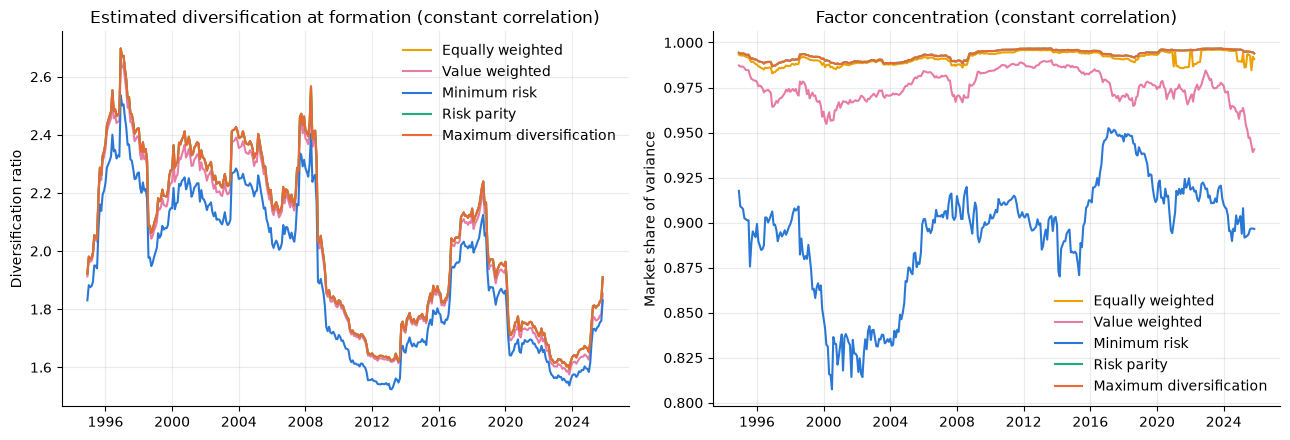

In [19]:
covs_cc = estimate_covs(w_cc["max_div"], rets, mkt, rf, T=T, estimator="const_corr")
conc_cc = concentration_diagnostics(w_cc, covs_cc, factor_covs=covs)
checks = diversification_checks(w_cc, covs_cc, conc_cc)
assert checks["dr_excess"] <= 1e-6        # MaxDiv has the highest estimated DR on every date
assert checks["max_kkt"] < 1e-8
assert checks["max_rp_dispersion"] < 1e-8
print(f"MaxDiv maximum relative KKT residual: {checks['max_kkt']:.2e}")
print(f"Maximum risk-parity contribution dispersion: {checks['max_rp_dispersion']:.2e}")

conc_table_cc = concentration_table(conc_cc)
display(conc_table_cc)
plot_diversification(conc_cc, " (constant correlation)")
save_figure("diversification_const_corr"); plt.show()

## 12. Shrunk sample covariance: sections 6–8 repeated

The jumps after 2020 in the charts below come from the shrinkage intensity λ; see 12.4.

### 12.1 Cumulative returns (shrunk sample)

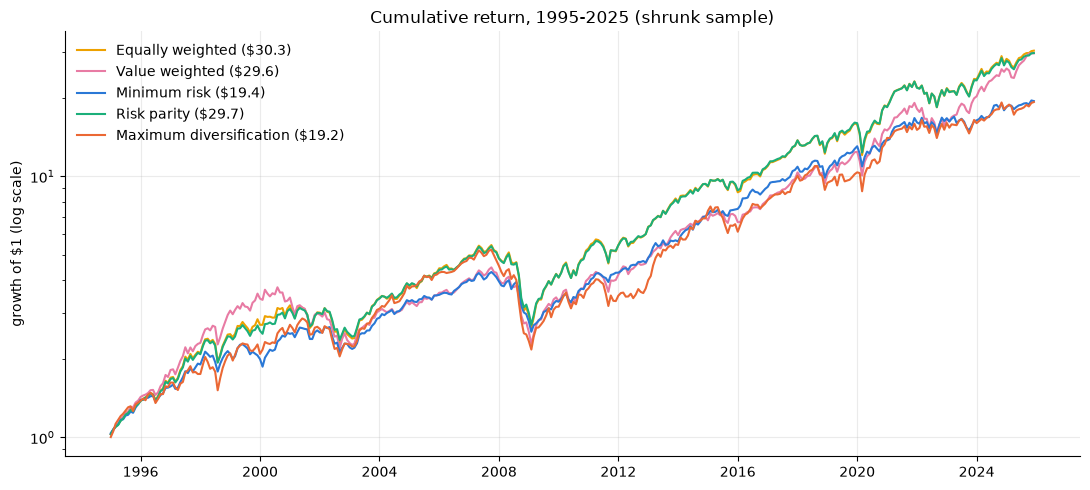

In [20]:
r_ss, w_ss = runs["shrunk_sample"]["returns"], runs["shrunk_sample"]["weights"]
plot_cumulative(r_ss, f"Cumulative return, {START_YEAR}-{END_YEAR} (shrunk sample)")
save_figure("cumulative_returns_shrunk_sample"); plt.show()

### 12.2 Drawdowns and economic subperiods (shrunk sample)

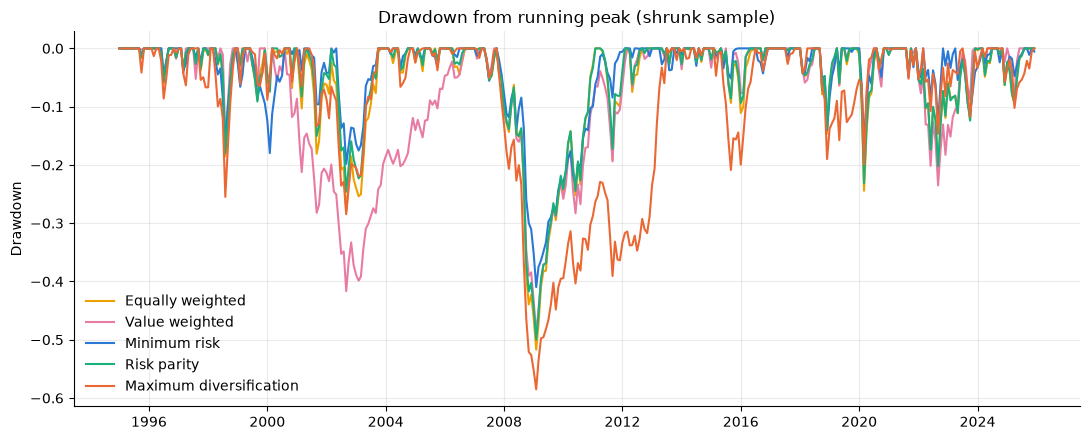

ann_return  ann_vol  sharpe  max_drawdown   beta
period    strategy                                                                 
1995–1999 Equally weighted             0.2316   0.1395  1.2173       -0.1851 0.9350
          Value weighted               0.2885   0.1396  1.5466       -0.1522 0.9512
          Minimum risk                 0.1554   0.1148  0.8868       -0.1610 0.6102
          Risk parity                  0.2182   0.1343  1.1763       -0.1798 0.8863
          Maximum diversification      0.1780   0.1613  0.7926       -0.2548 0.9407
2000–2002 Equally weighted            -0.0427   0.1849 -0.3450       -0.2802 0.8728
          Value weighted              -0.1273   0.1797 -0.8721       -0.4167 0.8945
          Minimum risk                 0.0346   0.1430  0.0509       -0.1983 0.4680
          Risk parity                 -0.0186   0.1693 -0.2462       -0.2460 0.7517
          Maximum diversification      0.0015   0.1695 -0.1252       -0.2845 0.7523
2003–2006 Equally weighted             0.1823   0.0985  1.5082       -0.0448 1.0704
          Value weighted               0.1414   0.0822  1.3567       -0.0431 0.9046
          Minimum risk                 0.1462   0.0737  1.5631       -0.0438 0.6604
          Risk parity                  0.1753   0.0877  1.6147       -0.0413 0.9553
          Maximum diversification      0.2007   0.0922  1.7751       -0.0660 0.7886
2007–2009 Equally weighted            -0.0452   0.2198 -0.1933       -0.5170 1.0792
          Value weighted              -0.0499   0.1901 -0.2824       -0.4913 0.9393
          Minimum risk                -0.0543   0.1538 -0.4196       -0.4098 0.7064
          Risk parity                 -0.0448   0.2071 -0.2166       -0.4998 1.0202
          Maximum diversification     -0.1261   0.2203 -0.5912       -0.5851 0.9770
2010–2019 Equally weighted             0.1420   0.1344  1.0221       -0.1914 1.0276
          Value weighted               0.1366   0.1242  1.0566       -0.1614 0.9559
          Minimum risk                 0.1436   0.0959  1.4012       -0.1397 0.5949
          Risk parity                  0.1430   0.1254  1.0934       -0.1727 0.9581
          Maximum diversification      0.1241   0.1485  0.8310       -0.2098 0.9238
2020–2025 Equally weighted             0.1127   0.1825  0.5323       -0.2444 0.9841
          Value weighted               0.1565   0.1719  0.7808       -0.2351 0.9627
          Minimum risk                 0.0728   0.1372  0.3872       -0.1638 0.6498
          Risk parity                  0.1077   0.1763  0.5190       -0.2313 0.9496
          Maximum diversification      0.1119   0.1660  0.5620       -0.1538 0.8073

In [21]:
plot_drawdowns(r_ss, "Drawdown from running peak (shrunk sample)")
save_figure("drawdowns_shrunk_sample"); plt.show()

sub_ss = subperiod_table(r_ss, w_ss, periods=PERIODS, rf=rf, asset_returns=rets, mkt=mkt)
display(sub_ss[SUB_COLS].rename(index=LABELS, level="strategy"))

### 12.3 Diversification and risk concentration (shrunk sample)

DR and risk contributions use the shrunk sample covariance the portfolios were built on; the market
share of variance uses the single-factor model of section 8, so it is comparable across estimators.

MaxDiv maximum relative KKT residual: 2.62e-08
Maximum risk-parity contribution dispersion: 9.31e-10


,div_ratio,n_held,eff_n_weight,eff_n_risk,top10_rc_share,systematic_share
Equally weighted,2.1130,500.0000,500.0000,466.1934,0.0375,0.9912
Value weighted,2.0463,500.0000,112.2817,104.0735,0.2447,0.9755
Minimum risk,2.3977,108.0511,67.6264,67.6263,0.2874,0.8717
Risk parity,2.1658,500.0000,475.9375,500.0000,0.0200,0.9912
Maximum diversification,2.7427,71.7903,40.6987,28.9774,0.4954,0.5818


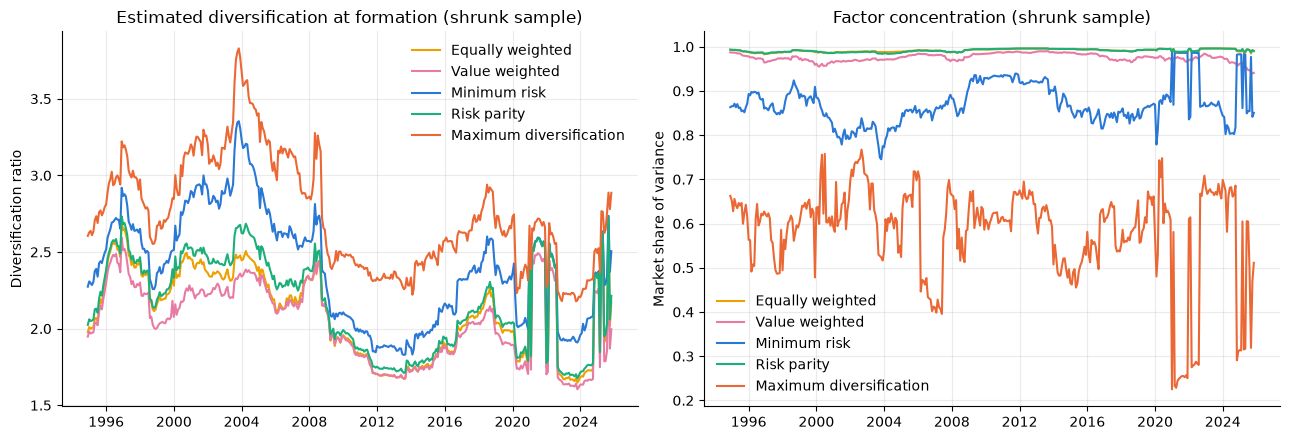

In [22]:
covs_ss = estimate_covs(w_ss["max_div"], rets, mkt, rf, T=T, estimator="shrunk_sample")
conc_ss = concentration_diagnostics(w_ss, covs_ss, factor_covs=covs)
checks = diversification_checks(w_ss, covs_ss, conc_ss)
assert checks["dr_excess"] <= 1e-6        # MaxDiv has the highest estimated DR on every date
assert checks["max_kkt"] < 1e-6  # numerical QP here, not a closed form
assert checks["max_rp_dispersion"] < 1e-8
print(f"MaxDiv maximum relative KKT residual: {checks['max_kkt']:.2e}")
print(f"Maximum risk-parity contribution dispersion: {checks['max_rp_dispersion']:.2e}")

conc_table_ss = concentration_table(conc_ss)
display(conc_table_ss)
plot_diversification(conc_ss, " (shrunk sample)")
save_figure("diversification_shrunk_sample"); plt.show()

### 12.4 Shrinkage intensity

λ is driven by fourth moments of returns, so a single extreme stock-month can dominate it. When
λ approaches one, the estimate is almost the constant target (equal variances, equal covariances),
under which minimum risk and MaxDiv move towards equal weights. We keep the estimator exactly as
specified in `project.pdf`.

Largest lambda 0.946 at 202101; largest return in that window: GME +1625% in 202101
Mean lambda: 0.925 on the 24 dates with GME 202101 in the window, 0.473 on the other 348


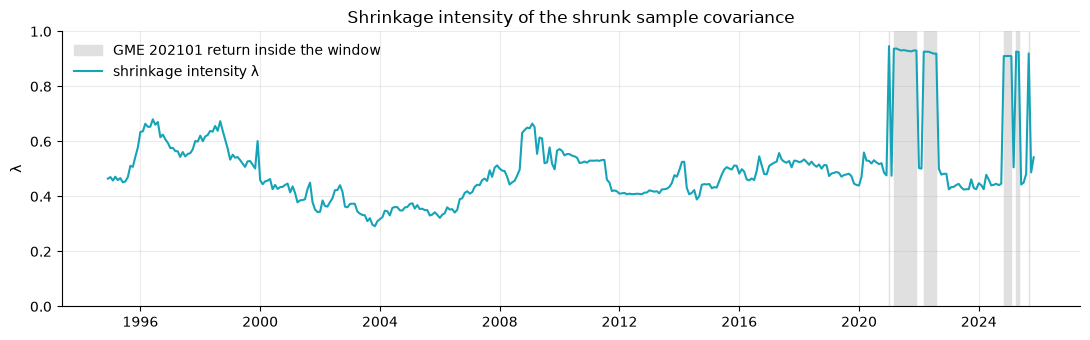

In [23]:
lam = pd.Series({t: c.lam for t, c in covs_ss.items()})

# Largest single return inside the window where lambda peaks
t_max = lam.idxmax()
i_max = idx.get_loc(t_max)
window_rets = rets.loc[idx[i_max - T + 1:i_max + 1], w_ss["ew"].loc[t_max].dropna().index].stack()
month, permno = window_rets.abs().idxmax()
ticker = crsp.loc[crsp.permno == permno, "ticker"].dropna().iloc[-1]
print(f"Largest lambda {lam.max():.3f} at {t_max}; largest return in that window: "
      f"{ticker} {window_rets[(month, permno)]:+.0%} in {month}")

# Formation dates whose window contains that stock-month
inside = pd.Series({t: permno in w_ss["ew"].loc[t].dropna().index
                       and idx.get_loc(t) - T < idx.get_loc(month) <= idx.get_loc(t) for t in lam.index})
print(f"Mean lambda: {lam[inside].mean():.3f} on the {inside.sum()} dates with {ticker} {month} in the window, "
      f"{lam[~inside].mean():.3f} on the other {(~inside).sum()}")

when_lam = pd.PeriodIndex(lam.index.astype(str), freq="M").to_timestamp()
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.fill_between(when_lam, 0, 1, where=inside.values, step="mid", color="0.88",
                label=f"{ticker} {month} return inside the window")
ax.plot(when_lam, lam, color=ESTIMATOR_COLORS["shrunk_sample"], label="shrinkage intensity λ")
ax.set(ylim=(0, 1), ylabel="λ", title="Shrinkage intensity of the shrunk sample covariance")
ax.legend(frameon=False, loc="upper left")
plt.tight_layout(); save_figure("shrinkage_intensity"); plt.show()

## Interpretation and limitations

Compare realized return and Sharpe alongside drawdowns, turnover and concentration. A higher
estimated DR does not guarantee better out-of-sample performance.

The covariance estimator matters most for minimum risk. The single-factor model treats residuals
as uncorrelated, and the optimizer exploits this by holding low-beta utilities (52% average
weight) whose shared industry risk the model cannot see: realized volatility is 1.74 times the
forecast (predicted/realized 0.57). The shrunk sample covariance captures that correlation, so
the utilities weight falls to 20% and the forecast is roughly unbiased (1.11). Constant
correlation removes less of the bias (0.83), since it gives every pair the same correlation.

Limitations:

* Rankings are point estimates from one 31-year sample; no Sharpe-ratio significance test is
  performed, and differences of a few hundredths should not be read as reliable rankings.
* Results exclude transaction costs. Under the shrunk sample covariance, minimum risk and MaxDiv
  trade more (180% and 261% annual one-way turnover).
* The shrinkage intensity λ is driven by fourth moments: GameStop's +1,625% return in January
  2021 raises λ to 0.925 on average on the 24 formation dates whose window contains it, versus
  0.473 on the other 348 (section 12.4), moving
  minimum risk and MaxDiv towards equal weights and adding turnover. The estimator is kept as
  specified in `project.pdf`; winsorizing returns before estimation would remove these jumps.
* Under constant correlation, MaxDiv and risk parity are the same inverse-volatility portfolio,
  so that estimator cannot separate the two rules. The shrunk sample estimator ignores sample
  means and uses one shrinkage target.
* The complete 60-month-history rule favors longer-listed stocks. Missing next-month returns
  earn RF, a simplifying assumption rather than an observed liquidation price. The download SQL
  filters US common stocks before saving; the cache omits those classification columns, so its
  provenance must be retained. Utilities are SIC 4900–4999 at the formation date.
* Position caps and HRP are optional extensions not explored here.

## Main findings

* **Single-factor baseline.** Risk parity has the highest full-sample Sharpe (0.689), with returns
  close to EW and lower volatility. Minimum risk has the lowest volatility (12.72%) and smallest
  maximum drawdown (−37.55%), alongside the lowest return (8.20%).
* MaxDiv achieves the highest average estimated DR (3.661), while holding about 63 of 500 stocks.
  Its market variance share (65.48%) is the lowest of the five; its stock risk contributions
  remain concentrated. Its realized Sharpe (0.604) trails RP, EW and VW, and its annual one-way
  turnover (160.36%) is the highest.
* Rankings depend on the economic period: MaxDiv has the highest Sharpe in 2010–2019 (1.207),
  whereas VW leads in 1995–1999 and 2020–2025, and minimum risk leads in 2000–2009.
* **The covariance estimator changes minimum risk the most.** With the shrunk sample covariance,
  minimum risk has the lowest volatility of every portfolio (11.75%) and its Sharpe rises from
  0.499 to 0.675, as the utilities weight falls from 52% to 20%. The cost is a deeper maximum
  drawdown (−40.98% vs −37.55%) and higher turnover (180% vs 117%).
* **MaxDiv is estimator-sensitive in both directions:** Sharpe 0.604 (single factor), 0.661
  (constant correlation, where it equals inverse-volatility risk parity) and 0.532 (shrunk sample,
  with 261% turnover).
* **Risk parity is the most robust rule:** Sharpe 0.656–0.689 and turnover 57–64% across all
  three estimators, close to EW and VW.
* VW has annual one-way turnover of only 10.01%. Gross performance comparisons should be read
  alongside these trading requirements; no net-of-cost ranking is established here.

In [24]:
# Optional exports for the slide deck; no effect on the submitted input files.
if EXPORT_REPORT_ASSETS:
    ASSET_DIR.mkdir(parents=True, exist_ok=True)
    table.rename(index=LABELS).to_csv(ASSET_DIR / "performance.csv")
    exhibit.to_csv(ASSET_DIR / "exhibit1.csv")
    sub.rename(index=LABELS, level="strategy").to_csv(ASSET_DIR / "subperiods.csv")
    conc_table.to_csv(ASSET_DIR / "concentration.csv")
    returns.to_csv(ASSET_DIR / "monthly_returns.csv")
    comparison.to_csv(ASSET_DIR / "estimator_comparison.csv")
    for est, sub_e, conc_e in [("const_corr", sub_cc, conc_table_cc), ("shrunk_sample", sub_ss, conc_table_ss)]:
        sub_e.rename(index=LABELS, level="strategy").to_csv(ASSET_DIR / f"subperiods_{est}.csv")
        conc_e.to_csv(ASSET_DIR / f"concentration_{est}.csv")
        runs[est]["returns"].to_csv(ASSET_DIR / f"monthly_returns_{est}.csv")
print("Completed: five strategies under three covariance estimators, drawdowns, subperiods and numerical checks.")

Completed: five strategies under three covariance estimators, drawdowns, subperiods and numerical checks.


## References

- Clarke, de Silva and Thorley (2013), *Risk Parity, Maximum Diversification, and
  Minimum Variance: An Analytic Perspective*, Journal of Portfolio Management 39(3),
  39–53. Exhibit 1 motivates the comparison table; this demo adds labeled total-return
  CAGR, drawdown and turnover. Our universe, period and residual-risk estimation differ.
- Clarke, de Silva and Thorley (2006), *Minimum-Variance Portfolios in the U.S.
  Equity Market*, Journal of Portfolio Management 33(1), 10–24. Exhibit 4 motivates
  the cumulative-return comparison, and its technical appendix gives the shrunk sample
  covariance of section 9; the demo clearly labels its compounded total
  growth of $1 and logarithmic scale.
- CRSP monthly stock file (`msf_v2`) through WRDS; Kenneth French market excess
  return and risk-free rate supplied in the course `MktRf.csv`.